In [1]:
## Import potřebných modulů a knihoven pro analýzu a vizualizaci dat.
# Importuje funkci curve_fit z modulu scipy.optimize pro nelineární přizpůsobení křivky
from scipy.optimize import curve_fit

# Importuje modul matplotlib.pylab pro vytváření grafů
import matplotlib.pylab as plt

# Importuje modul numpy pro práci s poli a matematickými funkcemi
import numpy as np

# Importuje modul os pro interakci s operačním systémem
import os

In [2]:
## Fitování kvadratických funkcí a výpis výsledků s nejistotami.
from uncertainties import ufloat
# Definice kvadratické funkce
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c
# Data pro x-ovou osu
x_data = np.array([10, 25, 50, 100])
# Data pro první peak
A_2f = np.array([0.365, 0.883, 1.559, 2.587])
H_2f = np.array([0.242, 0.594, 1.055, 1.804])
y_spread = np.array([0.006, 0.017, 0.029, 0.048])

# Fitování pro první peak
best_fit_A2f, covar_A2f = curve_fit(quadratic, x_data, A_2f, sigma=y_spread, absolute_sigma=True)
sigma_A2f = np.sqrt(np.diagonal(covar_A2f))

best_fit_H2f, covar_H2f = curve_fit(quadratic, x_data, H_2f, sigma=y_spread, absolute_sigma=True)
sigma_H2f = np.sqrt(np.diagonal(covar_H2f))
# Data pro druhý peak
B_2f = np.array([0.466, 1.083, 1.961, 3.326])
G_2f = np.array([0.313, 0.732, 1.338, 2.311])
y1_spread = np.array([0.011, 0.022, 0.029, 0.062])

# Fitování pro druhý peak
best_fit_B2f, covar_B2f = curve_fit(quadratic, x_data, B_2f, sigma=y1_spread, absolute_sigma=True)
sigma_B2f = np.sqrt(np.diagonal(covar_B2f))

best_fit_G2f, covar_G2f = curve_fit(quadratic, x_data, G_2f, sigma=y1_spread, absolute_sigma=True)
sigma_G2f = np.sqrt(np.diagonal(covar_G2f))

# Výpis výsledků s nejistotami
a1 = ufloat(best_fit_A2f[0], sigma_A2f[0])
b1 = ufloat(best_fit_A2f[1], sigma_A2f[1])
c1 = ufloat(best_fit_A2f[2], sigma_A2f[2])
print(f"Nejvhodnější (polynomické) parametry pro A_2f:\n a = {a1}\n b = {b1}\n c = {c1}")

a2 = ufloat(best_fit_H2f[0], sigma_H2f[0])
b2 = ufloat(best_fit_H2f[1], sigma_H2f[1])
c2 = ufloat(best_fit_H2f[2], sigma_H2f[2])
print(f"Nejvhodnější (polynomické) parametry pro H_2f:\n a = {a2}\n b = {b2}\n c = {c2}")

a3 = ufloat(best_fit_B2f[0], sigma_B2f[0])
b3 = ufloat(best_fit_B2f[1], sigma_B2f[1])
c3 = ufloat(best_fit_B2f[2], sigma_B2f[2])
print(f"Nejvhodnější (polynomické) parametry pro A_2f:\n a = {a3}\n b = {b3}\n c = {c3}")

a4 = ufloat(best_fit_G2f[0], sigma_G2f[0])
b4 = ufloat(best_fit_G2f[1], sigma_G2f[1])
c4 = ufloat(best_fit_G2f[2], sigma_G2f[2])
print(f"Nejvhodnější (polynomické) parametry pro H_2f:\n a = {a4}\n b = {b4}\n c = {c4}")

Nejvhodnější (polynomické) parametry pro A_2f:
 a = -0.000118+/-0.000014
 b = 0.0376+/-0.0013
 c = 0.002+/-0.015
Nejvhodnější (polynomické) parametry pro H_2f:
 a = (-7.1+/-1.4)e-05
 b = 0.0251+/-0.0013
 c = -0.001+/-0.015
Nejvhodnější (polynomické) parametry pro A_2f:
 a = -0.000117+/-0.000017
 b = 0.0446+/-0.0016
 c = 0.033+/-0.021
Nejvhodnější (polynomické) parametry pro H_2f:
 a = (-7.2+/-1.7)e-05
 b = 0.0300+/-0.0016
 c = 0.020+/-0.021


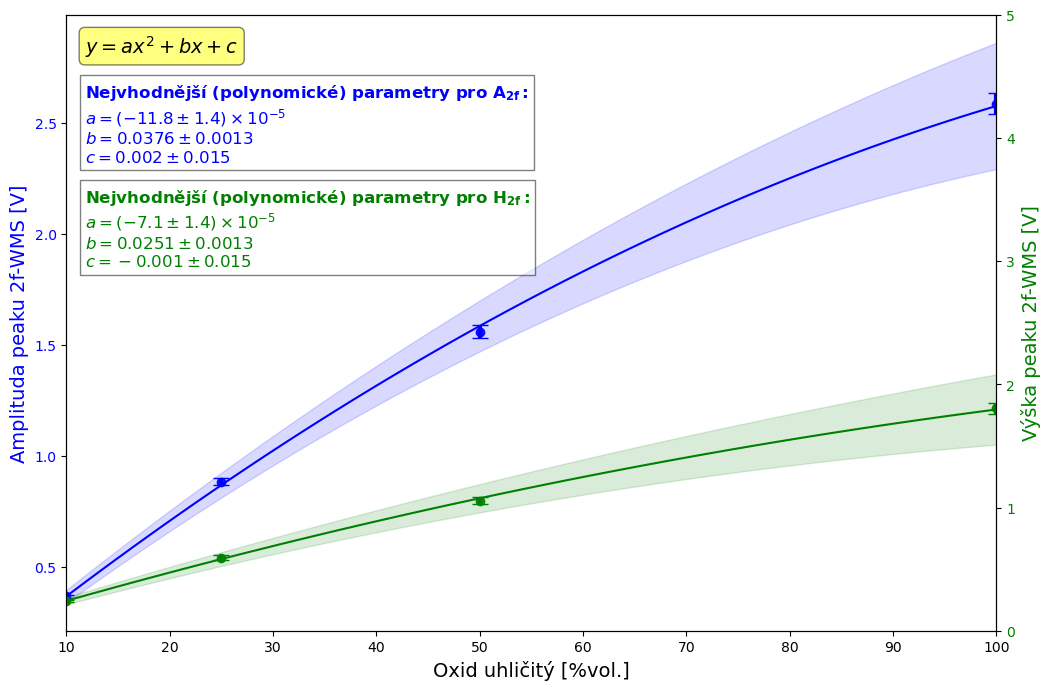

In [3]:
## Fitování a vizualizace polynomických křivek pro experimentální data - peak 1.
# Určení velikosti grafu
fig, ax1 = plt.subplots(figsize=(12, 8))

# Nastavení pro A_2f (modrá)
color = 'blue'
ax1.set_xlabel('Oxid uhličitý [%vol.]', fontsize=14)
ax1.set_ylabel('Amplituda peaku 2f-WMS [V]', color=color, fontsize=14)
ax1.tick_params(axis='y', labelcolor=color)
ax1.errorbar(x_data, A_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor=color)
ax1.scatter(x_data, A_2f, marker='o', facecolor=color, alpha=0.9, label='A_2f')
hires_x = np.linspace(10, 100, 100)
ax1.plot(hires_x, quadratic(hires_x, *best_fit_A2f), color=color, label='Fit A_2f')
ax1.fill_between(hires_x, quadratic(hires_x, *(best_fit_A2f + sigma_A2f)), quadratic(hires_x, *(best_fit_A2f - sigma_A2f)), color=color, alpha=0.15)

# Nastavení pro H_2f (zelená)
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Výška peaku 2f-WMS [V]', color=color2, fontsize=14)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.errorbar(x_data, H_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor=color2)
ax2.scatter(x_data, H_2f, marker='o', facecolor=color2, alpha=0.9, label='H_2f')
ax2.plot(hires_x, quadratic(hires_x, *best_fit_H2f), color=color2, label='Fit H_2f')
ax2.fill_between(hires_x, quadratic(hires_x, *(best_fit_H2f + sigma_H2f)), quadratic(hires_x, *(best_fit_H2f - sigma_H2f)), color=color2, alpha=0.15)

plt.xlim(10, 100)
plt.ylim(0, 5)
# Přidání rovnice do grafu v žlutém textovém poli
textstr = r'$y = ax^2 + bx + c$'
props = dict(boxstyle='round', facecolor='yellow', alpha=0.5)
ax1.text(0.02, 0.97, textstr, transform=ax1.transAxes, fontsize=14, verticalalignment='top', bbox=props)

# Přidání parametrů pro A_2f v modré barvě
param_text_A2f = '\n'.join((
    r'$\mathbf{Nejvhodnější\ (polynomické)\ parametry\ pro\ A_{2f}:}$',
    r'$a = (%.1f \pm %.1f) \times 10^{-5}$' % (best_fit_A2f[0] * 1e5, sigma_A2f[0] * 1e5),
    r'$b = %.4f \pm %.4f$' % (best_fit_A2f[1], sigma_A2f[1]),
    r'$c = %.3f \pm %.3f$' % (best_fit_A2f[2], sigma_A2f[2]),
))
ax1.text(0.02, 0.89, param_text_A2f, transform=ax1.transAxes, fontsize=12, verticalalignment='top', color='blue', bbox=dict(facecolor='white', alpha=0.5))

# Přidání parametrů pro H_2f v zelené barvě
param_text_H2f = '\n'.join((
    r'$\mathbf{Nejvhodnější\ (polynomické)\ parametry\ pro\ H_{2f}:}$',
    r'$a = (%.1f \pm %.1f) \times 10^{-5}$' % (best_fit_H2f[0] * 1e5, sigma_H2f[0] * 1e5),
    r'$b = %.4f \pm %.4f$' % (best_fit_H2f[1], sigma_H2f[1]),
    r'$c = %.3f \pm %.3f$' % (best_fit_H2f[2], sigma_H2f[2]),
))
ax1.text(0.02, 0.72, param_text_H2f, transform=ax1.transAxes, fontsize=12, verticalalignment='top', color='green', bbox=dict(facecolor='white', alpha=0.5))
# Uložení grafu jako obrázek
plt.savefig("polyn_graph_peak1.png")
# Zobrazení grafu
plt.show()


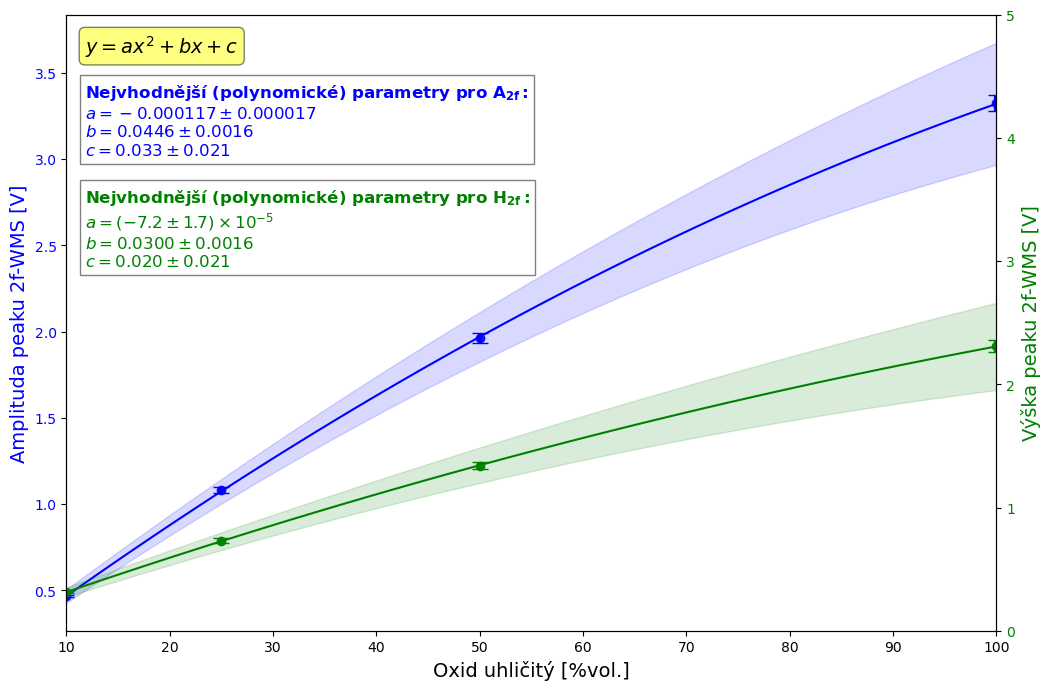

In [4]:
## Fitování a vizualizace polynomických křivek pro experimentální data - peak 2.
#Určení velikosti grafu
fig, ax1 = plt.subplots(figsize=(12, 8))

# Nastavení pro B_2f (modrá)
color =  'blue'
ax1.set_xlabel('Oxid uhličitý [%vol.]', fontsize=14)
ax1.set_ylabel('Amplituda peaku 2f-WMS [V]', color=color, fontsize=14)
ax1.tick_params(axis='y', labelcolor=color)
ax1.errorbar(x_data, B_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor=color)
ax1.scatter(x_data, B_2f, marker='o', facecolor=color, alpha=0.9, label='B_2f')
hires_x = np.linspace(10, 100, 100)
ax1.plot(hires_x, quadratic(hires_x, *best_fit_B2f), color=color, label='Fit B_2f')
ax1.fill_between(hires_x, quadratic(hires_x, best_fit_B2f[0] + sigma_B2f[0], best_fit_B2f[1] + sigma_B2f[1], best_fit_B2f[2] + sigma_B2f[2]), quadratic(hires_x, best_fit_B2f[0] - sigma_B2f[0], best_fit_B2f[1] - sigma_B2f[1], best_fit_B2f[2] - sigma_B2f[2]), color=color, alpha=0.15)

# Nastavení pro G_2f (zelená)
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Výška peaku 2f-WMS [V]', color=color2, fontsize=14)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.errorbar(x_data, G_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor=color2)
ax2.scatter(x_data, G_2f, marker='o', facecolor=color2, alpha=0.9, label='G_2f')
ax2.plot(hires_x, quadratic(hires_x, *best_fit_G2f), color=color2, label='Fit G_2f')
ax2.fill_between(hires_x, quadratic(hires_x, best_fit_G2f[0] + sigma_G2f[0], best_fit_G2f[1] + sigma_G2f[1], best_fit_G2f[2] + sigma_G2f[2]), quadratic(hires_x, best_fit_G2f[0] - sigma_G2f[0], best_fit_G2f[1] - sigma_G2f[1], best_fit_G2f[2] - sigma_G2f[2]), color=color2, alpha=0.15)

plt.xlim(10, 100)
plt.ylim(0, 5)
# Přidání rovnice do grafu v žlutém textovém poli
textstr = r'$y = ax^2 + bx + c$'
props = dict(boxstyle='round', facecolor='yellow', alpha=0.5)
ax1.text(0.02, 0.97, textstr, transform=ax1.transAxes, fontsize=14, verticalalignment='top', bbox=props)

# Přidání parametrů pro B_2f v žluté barvě
param_text_B2f = '\n'.join((
    r'$\mathbf{Nejvhodnější\ (polynomické)\ parametry\ pro\ A_{2f}:}$',
    r'$a = %.6f \pm %.6f$' % (best_fit_B2f[0], sigma_B2f[0]),
    r'$b = %.4f \pm %.4f$' % (best_fit_B2f[1], sigma_B2f[1]),
    r'$c = %.3f \pm %.3f$' % (best_fit_B2f[2], sigma_B2f[2]),
))
ax1.text(0.02, 0.89, param_text_B2f, transform=ax1.transAxes, fontsize=12, verticalalignment='top', color='blue', bbox=dict(facecolor='white', alpha=0.5))

# Přidání parametrů pro G_2f v zelené barvě
param_text_G2f = '\n'.join((
    r'$\mathbf{Nejvhodnější\ (polynomické)\ parametry\ pro\ H_{2f}:}$',
    r'$a = (%.1f \pm %.1f) \times 10^{-5}$' % (best_fit_G2f[0] * 1e5, sigma_G2f[0] * 1e5),
    r'$b = %.4f \pm %.4f$' % (best_fit_G2f[1], sigma_G2f[1]),
    r'$c = %.3f \pm %.3f$' % (best_fit_G2f[2], sigma_G2f[2]),
))
ax1.text(0.02, 0.72, param_text_G2f, transform=ax1.transAxes, fontsize=12, verticalalignment='top', color='green', bbox=dict(facecolor='white', alpha=0.5))
# Uložení grafu jako obrázek
plt.savefig("polyn_graph_peak2.png")
# Zobrazení grafu
plt.show()